<a href="https://colab.research.google.com/github/GuilhermeFernandez/climate_resilient_pastures/blob/main/Esboco_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 1
### Objetivos:

Foco: Definir a base estática e limpar os polígonos.

Devo gerar um GeoJSON/Dataframe contendo:

1.   ID_Area: Identificador único; ✅
2.   nm_mun: município do polígono; ✅
3. classe_manejo: Categoria fixa (Extensivo, Rotacionado, SSP Nativas, SSP Exóticas);
4. geometry: Polígono da propriedade; ✅
5. area_ha: Área calculada da geometria útil. ✅
6. date_implementation: Ano em que o sistema foi implantado.
7. %_cobertura_arborea: calculada com modelo baseado em CBERS-4A, imagens de 2025 (se possível), máscara de recorte com buffer de 1pixel 8x8.










In [3]:
# @title Importando Bibliotecas necessárias
!pip install geobr
import sys, os, geobr
import geopandas as gpd
import pandas as pd

In [4]:
# @title Definindo diretório
path = '/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto'
files = [f for f in os.listdir(path) if f.endswith('.shp')]

In [5]:
# @title Extraindo geometrias dos shapefiles no diretório:
gdfs = []

for file in files:
    full_path = os.path.join(path, file)
    try:
        gdf_temp = gpd.read_file(full_path)
        gdfs.append(gdf_temp)
    except Exception as e:
        print(f"Erro ao ler {file}: {e}")

if gdfs:
    gdf = pd.concat(gdfs, ignore_index=True)

    #Ajuste de Projeção para Cálculo de Área:
    if gdf.crs is None:
        gdf.set_crs(epsg=32721, inplace=True) # Assumindo UTM 21S se não tiver nada -- já que a área de estudo é no Mato Grosso
    else:
        gdf = gdf.to_crs(epsg=32721) # Convertendo para UTM 21S se estiver em outro

    #Calculo da área:
    gdf['Area_ha'] = gdf.area / 10000

    #Converte para o CRS final de saída (SIRGAS 2000 Lat/Lon):
    gdf = gdf.to_crs(epsg=4674)

    #Cria o ID para a Área de Estudo e Salva
    gdf['ID_Area'] = gdf.index + 1

    output_file = os.path.join(path, 'study_areas.geojson')
    gdf.to_file(output_file, driver='GeoJSON')
    print("Arquivo salvo com sucesso!")
else:
    print("Nenhum arquivo shapefile encontrado.")

Arquivo salvo com sucesso!


In [6]:
# @title Extraindo município das coordenadas a partir de IBGE 2024
municipalities = geobr.read_municipality(code_muni='MT', year=2024)
gdf_mun = gpd.sjoin(gdf, municipalities[['name_muni', 'geometry']],
                             how='left',
                             predicate='intersects')
gdf_mun = gdf_mun.drop(['index_right', 'id'], axis=1)
gdf_mun.columns = ['geometry','area_ha','ID_Area','nm_mun']

In [7]:
gdf_mun.to_file('study_areas.geojson', driver='GeoJSON')

## Parte 2
### Objetivos:

Foco: Processamento pesado. Classificar cobertura e extrair índices para cada ano/mês dos 40 anos. A área deve ser recortada pela máscara gerada na Parte 1 para retirada de pixels com cobertura arbórea superior a 10%. Deve iterar sobre a coleção Landsat e CHIRPS e gerar um Dataframe contendo:

1.   ID_Area: Identificador único; ✅
2.   date: Ano; ✅
3. ndvi_value: Média (?) do NDVI apenas nos pixels de pasto;
4. ndmi_value: Média (?) do NDMI;
5. lst_value: Média (?) da temperatura de superfície;
6. precipitation_mm: Acumulado de chuva do CHIRPS para o período; ✅
7. precip_anomalies: para cada ano, True ou False. ✅


In [8]:
import ee
import json

In [9]:
ee.Authenticate()
ee.Initialize(project='ee-guilhermefernandez')

In [10]:
gdf = gpd.read_file('/content/study_areas.geojson')
gdf.to_crs(epsg=4674)

,area_ha,ID_Area,nm_mun,geometry
0,165.78976,1,Nova Guarita,"POLYGON ((-55.38248 -10.21095, -55.38102 -10.2..."


In [11]:
years = ee.List.sequence(1986, 2025)
rainfallCollection = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').select('precipitation')
precipitationData = []

In [12]:
def calculateAnnualPrecipitation(year):
    startDateYear = ee.Date.fromYMD(year, 1, 1)
    endDateYear = ee.Date.fromYMD(year, 12, 31).advance(1, 'day')
    annualRainfall = rainfallCollection.filter(ee.Filter.date(startDateYear, endDateYear)).sum()
    rainfallMean = annualRainfall.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi.geometry(),
        scale=5566,
        maxPixels=1e9
    )
    return ee.Feature(None, {
        'year': year,
        'precipitation': rainfallMean.get('precipitation')
    })

In [13]:
for index, row in gdf.iterrows():
  geom = ee.Geometry(row.geometry.__geo_interface__)
  id_area = row['ID_Area'] if 'ID_Area' in gdf.columns else index
  aoi = ee.Feature(geom, {'ID_Area': id_area})


  annualRainfallData = years.map(calculateAnnualPrecipitation)
  rainfallInfo = annualRainfallData.getInfo()

  for feature in rainfallInfo:
        props = feature['properties']
        if props.get('precipitation') is not None:
            precipitationData.append({
                'ID_Area': id_area,
                'year': props['year'],
                'precipitation': props['precipitation']
            })

In [14]:
df_metricas = pd.DataFrame(precipitationData)
df_metricas = df_metricas.sort_values(by=['ID_Area', 'year']).reset_index(drop=True)

df_metricas.to_csv('metricas.csv', index=False)

In [15]:
averagePrecipitation = df_metricas['precipitation'].mean()
dp_precipitation = df_metricas['precipitation'].std()
df_metricas['precip_anomalies'] = df_metricas['precipitation'] < averagePrecipitation - dp_precipitation
df_metricas['precip_anomalies'].sum()



print(averagePrecipitation)
print(df_metricas)

2165.320087701896
    ID_Area  year  precipitation  precip_anomalies
0         1  1986    2060.799708             False
1         1  1987    1864.352250              True
2         1  1988    2191.557225             False
3         1  1989    2514.162230             False
4         1  1990    2266.888193             False
5         1  1991    2347.565198             False
6         1  1992    2378.898900             False
7         1  1993    2102.339801             False
8         1  1994    2288.600283             False
9         1  1995    2365.948991             False
10        1  1996    2102.509553             False
11        1  1997    1938.349090              True
12        1  1998    2012.133832             False
13        1  1999    1987.538419             False
14        1  2000    2244.080724             False
15        1  2001    2090.036788             False
16        1  2002    1904.208280              True
17        1  2003    2219.958349             False
18        1  

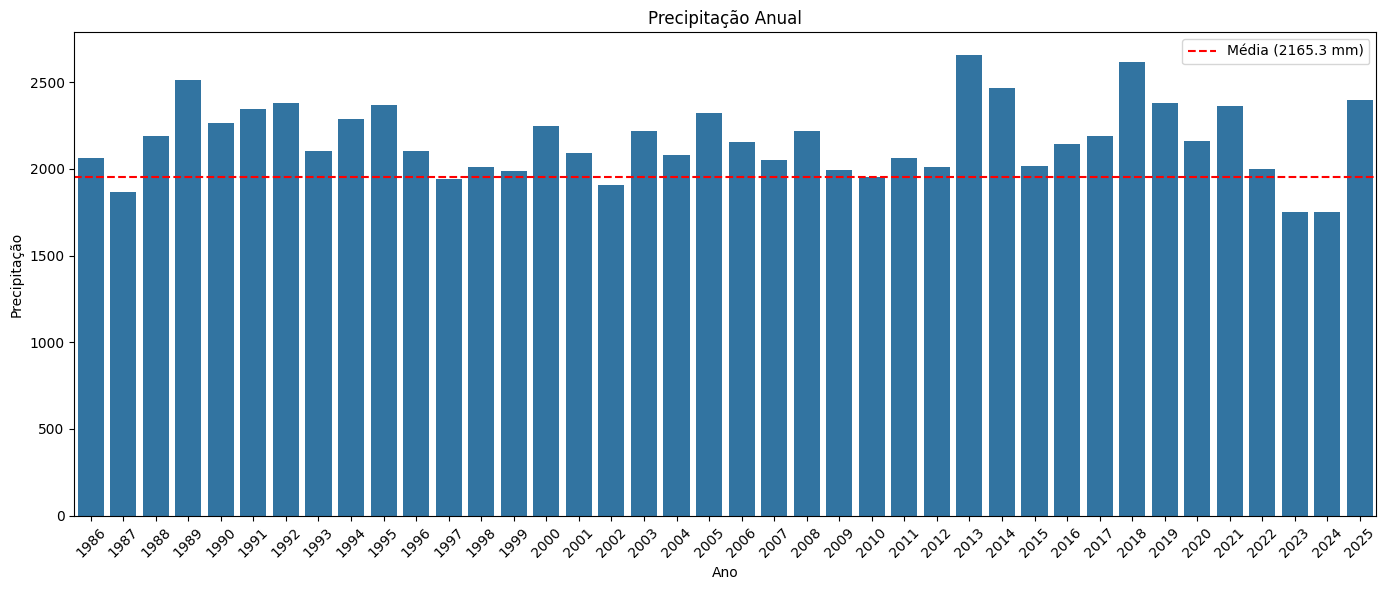

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
p = sns.barplot(x='year', y='precipitation', data=df_metricas)
plt.axhline(y=averagePrecipitation - dp_precipitation, color='red', linestyle='dashed', label=f'Média ({averagePrecipitation:.1f} mm)')
plt.xticks(rotation=45)
plt.title('Precipitação Anual')
plt.xlabel('Ano')
plt.ylabel('Precipitação')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
df_metricas['precip_anomalies'].sum()

np.int64(5)

## Parte 3
### Objetivos:

Foco: Transformar dados em resultados.

Deve ler o Dataframe do Script 2 e gerar um Dataframe de Resultados contendo:


1.   ID_Area: Identificador único; ✅
2.   Index: Coluna indicando qual índice (NDVI, NDMI ou LST):
> 3. Senslope_trend_pre: Valor da inclinação da tendência ao longo da série;
> 4. Senslope_trend_post: Valor da inclinação da tendência ao longo da série após implementação, se houver;
> 5. trend_significance_pre: Valor-p do teste Mann-Kendall;
> 6. trend_significance_post: Valor-p do teste Mann-Kendall;
> 7. z_score_drought: O desvio padrão do índice durante os anos de anomalia climática (secas identificadas = precip_anomalies == True);
> 8. comparative_resilience: Rótulo final (Brightspot, Hotspot ou Neutro) baseado na comparação com vizinhos em períodos de anomalia climática (secas identificadas = precip_anomalies == True).



